In [1]:
import pandas as pd
import numpy as np
import os
import mo_gymnasium as mo_gym
import gymnasium as gym
from env.user_sim import UserSimEnv
import env.simulate as sim_utils
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import utils
import process_data as dp
import mdp_utils
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from radar import radar_chart


%load_ext autoreload
%autoreload 2

Failed to read module file 'C:\Python311\Lib\urllib\parse.py' for module 'urllib.parse': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1206, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1178, in _find_and_load
  File "<frozen impor

In [2]:
NUM_VALS_PER_FEATURE = [2, 2, 2]
NUM_FEATURES = len(NUM_VALS_PER_FEATURE)
NUM_USER_STATES = np.prod(NUM_VALS_PER_FEATURE)
NUM_CLUSTERS = 6
MAX_COUNT = 2
NUM_COUNT_STATES = (MAX_COUNT+1)**NUM_CLUSTERS
NUM_STATES = NUM_USER_STATES * NUM_COUNT_STATES 
NUM_ACTIONS = NUM_CLUSTERS

cluster_col = 'cluster_all'
state_features = ['TIR', 'TIME_Q', 'MOT']
feature_names = ['Tiredness', 'Time available', 'Perceived usefulness']
cluster_vars = [ 'likedness', 'usefulness', 'difficulty']

reward_cols = ["obs_time", "obs_liked", "obs_pu", "r_expert", "r_diversity"]
obj_names = ["Time Required", "Fun", "Perceived Usefulness", "Expert Usefulness", "Diversity"]

NUM_OBJECTIVES = len(reward_cols)

In [3]:
results_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\results\\'

data_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\data\\'

action_file = 'challenge_info.csv'
actions = pd.read_csv(data_folder + action_file)

filename = 'processed_samples.csv'
samples = pd.read_csv(os.path.join(data_folder, filename))

In [4]:
def get_cluster_size(df, cluster_vars, cluster_n, min_samples=5):
    """Determine optimal cluster size based on silhouette score and minimum cluster size.
    args:
    - df: DataFrame with z-scores for coping strategy categories.
    - cluster_vars: List of column names to use for clustering.
    - cluster_n: List of integers representing different cluster sizes to evaluate.
    - min_samples: Minimum number of samples required in the smallest cluster.
    returns:
    - best_k: Optimal number of clusters."""
 
    scaler = StandardScaler()
    X = scaler.fit_transform(df[cluster_vars])
    
    sil_scores = []
    smallest_cluster_sizes = []
 
    # calculate silhouette scores for different cluster sizes
    for k in cluster_n:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X)
 
        sil_scores.append(silhouette_score(X, labels))
 
        # get sample size of smallest cluster
        cluster_counts = pd.Series(labels).value_counts()
        smallest_cluster_sizes.append(cluster_counts.min())
 
    # get optimal cluster n based on silhouette score
    best_k = cluster_n[np.argmax(sil_scores)]
 
    # if smallest cluster size is below min_samples, check other cluster n
    if smallest_cluster_sizes[np.argmax(sil_scores)] < min_samples:
        # get cluster n with largest smallest cluster
        best_k = cluster_n[np.argmax(smallest_cluster_sizes)]

    print(f"Silhouette scores: {sil_scores}")
 
    return best_k

In [5]:
overall_size = get_cluster_size(actions, cluster_vars, cluster_n=range(2, 13), min_samples=1)
print(f"Optimal cluster size: {overall_size}")

for col in cluster_vars:
    best_size = get_cluster_size(actions, [col], cluster_n=range(2, 13), min_samples=1)
    print(f"Optimal cluster size for {col}: {best_size}")

Silhouette scores: [0.3486637755053397, 0.3021018231381609, 0.3018635224307025, 0.3085324281188118, 0.29756553948436065, 0.2891999108641647, 0.2694950920280035, 0.28785561198101894, 0.26298042303602825, 0.25299566850733735, 0.25027720307817763]
Optimal cluster size: 2
Silhouette scores: [0.5599976646840227, 0.5525030181889601, 0.5784204123903209, 0.585823102363738, 0.5032392257694656, 0.5128999041489384, 0.5269329261976425, 0.5732519347254091, 0.5758936066071529, 0.589249250902464, 0.5905850167962322]
Optimal cluster size for likedness: 12
Silhouette scores: [0.658917888666504, 0.5914009433162121, 0.5192636797955958, 0.5371471857023882, 0.5507980476444385, 0.5794459575149048, 0.5753785751199602, 0.5465901818227696, 0.5270198040566613, 0.5593005188057546, 0.5410500103890326]
Optimal cluster size for usefulness: 2
Silhouette scores: [0.5688806621601533, 0.5178445646001637, 0.5243954284901401, 0.5345613441189115, 0.5377376679325381, 0.5241480996917913, 0.5314286387681387, 0.53912168938803

In [6]:
actions[cluster_vars + ['expert_score']].corr()

,likedness,usefulness,difficulty,expert_score
likedness,1.000000,0.679427,-0.325231,-0.180832
usefulness,0.679427,1.000000,-0.118284,0.094094
difficulty,-0.325231,-0.118284,1.000000,0.466103
expert_score,-0.180832,0.094094,0.466103,1.000000


In [7]:
# cluster actions by category and expert score
actions.groupby(['category', 'expert_score']).size().unstack(fill_value=0)
actions['cat_diff_cluster'] = actions.groupby(['category', 'expert_score']).ngroup()

In [8]:
actions.groupby('cat_diff_cluster')[cluster_vars].agg(['mean', 'count'])

likedness       usefulness       difficulty      
                      mean count       mean count       mean count
cat_diff_cluster                                                  
0                 6.100502     2   4.206020     2   2.861204     2
1                 5.738957     9   4.133012     9   3.282582     9
2                 5.894346    13   4.213920    13   3.540012    13
3                 6.255956     8   3.704843     8   1.875281     8
4                 5.792950    19   3.707256    19   2.999948    19
5                 5.846958     9   3.741953     9   3.681989     9
6                 5.715909     2   4.072727     2   2.679545     2
7                 6.114212     7   3.535123     7   2.726588     7
8                 4.754934    11   3.666635    11   3.606242    11
9                 5.392512     3   3.532307     3   2.695954     3
10                6.294586    13   4.306157    13   3.056039    13
11                6.048241     7   4.372712     7   3.541645     7

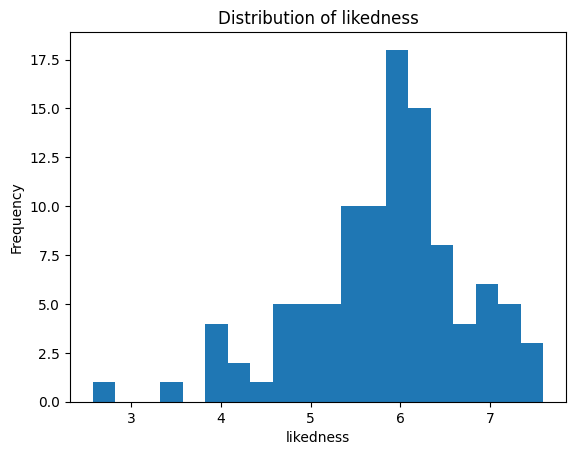

likedness - Mean: 5.83, Std: 0.91


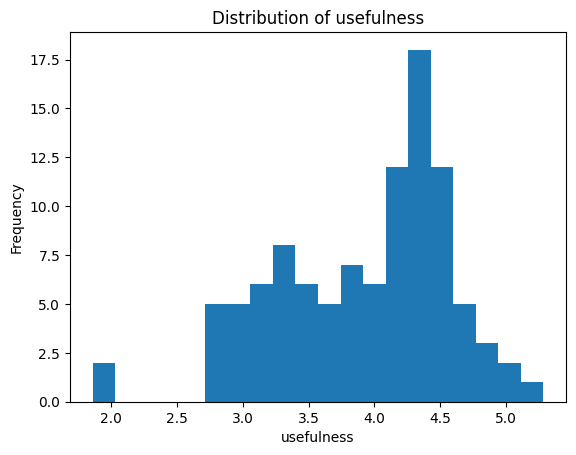

usefulness - Mean: 3.93, Std: 0.66


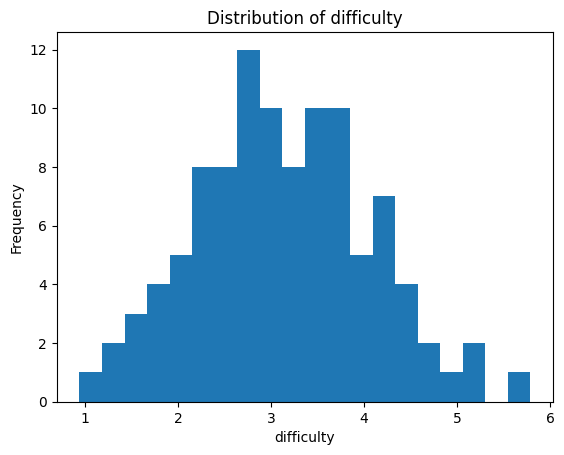

difficulty - Mean: 3.14, Std: 0.94


In [9]:
for var in cluster_vars:
    plt.figure()
    plt.hist(actions[var], bins=20)
    plt.title(f"Distribution of {var}")
    plt.xlabel(var)
    plt.ylabel("Frequency")
    plt.show()
    # print mean and std
    print(f"{var} - Mean: {actions[var].mean():.2f}, Std: {actions[var].std():.2f}")

In [29]:
num_clusters = 2
actions_clustered = actions.copy()
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(actions_clustered[cluster_vars])
actions_clustered[cluster_col] = kmeans.fit_predict(X_scaled)

# For each challenge category, perform clustering, then assign cluster labels back to the original DataFrame 
categories = actions_clustered['category'].unique()
for i in range(len(categories)):
    category = categories[i]
    category_data = actions_clustered[actions_clustered['category'] == category]
    X_scaled = scaler.fit_transform(category_data[cluster_vars])
    category_data[cluster_col] = kmeans.fit_predict(X_scaled)
    print(f"Category: {category}")
    print(category_data[cluster_col].value_counts())
    actions_clustered.loc[actions_clustered['category'] == category, cluster_col] = (i*2) + category_data[cluster_col]
    print(actions_clustered[actions_clustered['category'] == category][cluster_col].value_counts())

# stats = actions_clustered.groupby(cluster_col)[cluster_vars].agg(['mean', 'count'])
# means_df = stats.xs('mean', level=1, axis=1)
# means = means_df[cluster_vars].values
# for cluster in range(num_clusters):
#     print(f"Cluster {cluster}:")
#     print(means_df.loc[cluster])
#     actions_in_cluster = actions_clustered[actions_clustered[cluster_col] == cluster]
#     print(actions_in_cluster['challenge_id'].tolist())
#     print(actions_in_cluster.groupby('category').size())
# means = scaler.fit_transform(means)
# radar_chart(cluster_vars, means, groups=means_df.index.astype(str).tolist(), title='Mean Cluster Values', legend_position=(2,1))
# plt.show()
actions_clustered.head()

Category: acceptance
cluster_all
1    20
0     4
Name: count, dtype: int64
cluster_all
1    20
0     4
Name: count, dtype: int64
Category: distraction
cluster_all
0    20
1    16
Name: count, dtype: int64
cluster_all
2    20
3    16
Name: count, dtype: int64
Category: problem_solving
cluster_all
1    10
0    10
Name: count, dtype: int64
cluster_all
5    10
4    10
Name: count, dtype: int64
Category: social_support
cluster_all
0    20
1     3
Name: count, dtype: int64
cluster_all
6    20
7     3
Name: count, dtype: int64


,challenge_id,Type,Moeilijkheidsgraad,expert_score,category,likedness,difficulty,time_spent,usefulness,completion_rate,cat_diff_cluster,cluster_all
0,AC1,Photo,Moeilijk,1.00,acceptance,7.166667,2.041667,7.625000,4.458333,0.551724,2,1
1,AC10,Open,Moeilijk,1.00,acceptance,5.610169,3.576271,3.033898,4.355932,0.837838,2,1
2,AC11,Open,Moeilijk,1.00,acceptance,6.151515,2.060606,3.424242,4.303030,0.677419,2,1
3,AC12,Open,Gemiddeld,0.66,acceptance,5.907692,2.169231,1.892308,4.123077,0.926829,1,1
4,AC13,Photo,Moeilijk,1.00,acceptance,6.363636,4.545455,7.636364,4.090909,0.270270,2,1


In [30]:
# Take states into account when clustering
df, _ = dp.process_samples(samples, actions_clustered, state_features, NUM_VALS_PER_FEATURE, num_clusters=8, cluster_col=cluster_col)
# print nr of samples per (s,a) pair
df.groupby(['s_idx', cluster_col]).size().unstack(fill_value=0)


Number of samples after processing: 3111


cluster_all,0,1,2,3,4,5,6,7
s_idx,,,,,,,,
0,44,212,133,101,142,123,218,27
1,11,54,40,30,40,32,47,8
2,8,63,34,29,40,45,72,3
3,12,75,41,35,46,52,85,10
4,36,126,114,70,122,110,146,24
5,5,23,17,16,21,14,17,4
6,4,44,22,19,25,22,46,8
7,9,23,22,24,15,17,28,6


In [12]:
df.groupby('cluster_all').size()

cluster_all
0    100
1    358
2    593
3    406
4    816
5    392
6    446
dtype: int64